In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

In [17]:
files = [
    "extracted-sheets/2021-Daily Traffic Summary.csv",
    "extracted-sheets/2022-Daily Traffic Summary.csv",
    "extracted-sheets/2023-Daily Traffic Summary.csv"
]

Số ngày bị khuyết thiếu thực tế sau khi sửa định dạng: 0


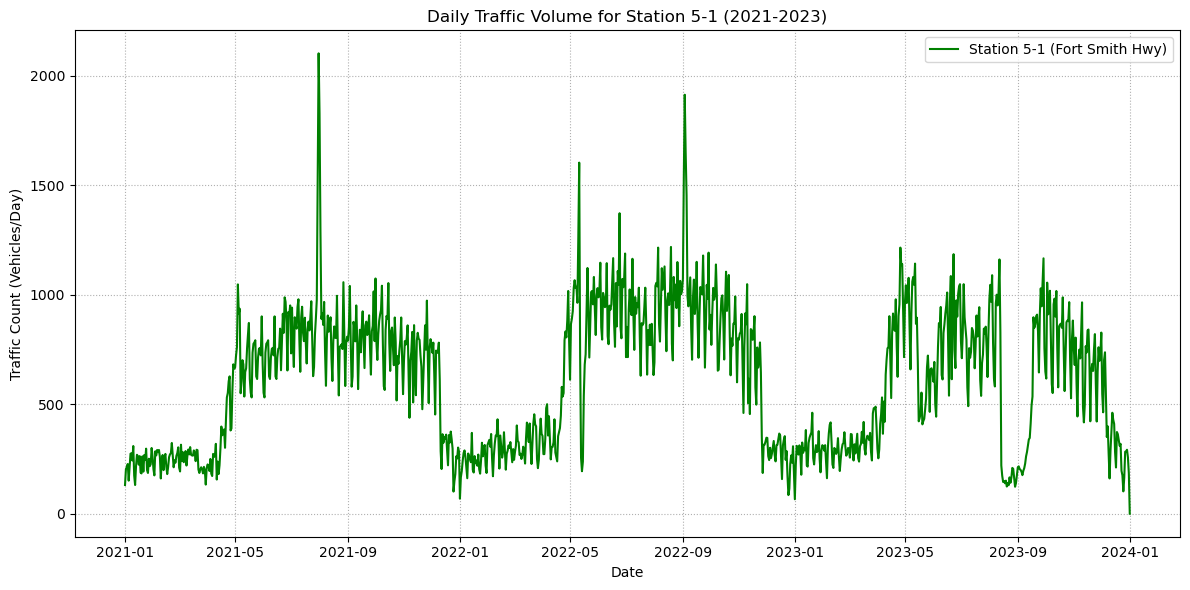

In [18]:
dfs_5_1 = []
for f in files:
    df = pd.read_csv(f)
    
    # DÙNG 'mixed': Ép Pandas tự động nhận diện thông minh cho từng dòng, 
    # tránh việc cấu hình sai làm mất sạch dữ liệu lưu lượng
    df['Date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce')
    
    df = df.dropna(subset=['Date'])
    df['5-1'] = pd.to_numeric(df['5-1'], errors='coerce')
    dfs_5_1.append(df[['Date', '5-1']])

# Gộp dữ liệu 3 năm
df_station = pd.concat(dfs_5_1, ignore_index=True).sort_values(by='Date').reset_index(drop=True)

# Gộp trùng ngày (nếu có dòng trùng mốc thời gian thì tính trung bình)
df_station = df_station.groupby('Date').mean().reset_index()

# Đặt Date làm chỉ mục (Index) cho chuỗi thời gian
df_station.set_index('Date', inplace=True)

# Làm liền chuỗi ngày (Thêm các ngày bị nhảy cóc nếu lịch trình bị thiếu)
df_station = df_station.asfreq('D')

# Kiểm tra xem thực tế có bị trống ngày nào không và tiến hành nội suy làm mượt dữ liệu
total_nan = df_station['5-1'].isnull().sum()
print(f"Số ngày bị khuyết thiếu thực tế sau khi sửa định dạng: {total_nan}")

if total_nan > 0:
    print("Đang tiến hành nội suy mượt cho các ngày thiếu nhỏ lẻ...")
    df_station['5-1'] = df_station['5-1'].interpolate(method='time')

# --- VẼ LẠI ĐỒ THỊ CHUẨN ---
plt.figure(figsize=(12, 6))
# Sử dụng df_station.index vì Date đã là Index
plt.plot(df_station.index, df_station['5-1'], label='Station 5-1 (Fort Smith Hwy)', color='green')
plt.title('Daily Traffic Volume for Station 5-1 (2021-2023)')
plt.xlabel('Date')
plt.ylabel('Traffic Count (Vehicles/Day)')
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()

#### 1. Kiểm định Augmented Dickey-Fuller (ADF Test)

Để kiểm tra tính dừng một cách khách quan thay vì nhìn bằng mắt thường, người ta sử dụng kiểm định giả thuyết toán học ADF dựa trên phương trình hồi quy sai phân sau:

$$\Delta Y_t = \alpha + \beta t + \gamma Y_{t-1} + \sum_{i=1}^{p} \delta_i \Delta Y_{t-i} + \epsilon_t$$

**Trong đó:**

* $\Delta Y_t = Y_t - Y_{t-1}$: Là sai phân bậc 1 của chuỗi tại thời điểm $t$.
* $\alpha$: Hằng số (hệ số chặn / drift).
* $\beta t$: Thành phần xu hướng theo thời gian (deterministic trend).
* $Y_{t-1}$: Giá trị trễ (lag 1) của chuỗi thời gian.
* $\gamma$: **Hệ số quan trọng nhất dùng để kiểm định.** Nếu $\gamma = 0$, chuỗi chứa một nghiệm đơn vị (unit root) và dịch chuyển không ngừng.
* $\delta_i$: Hệ số của các sai phân trễ bậc $i$ (được thêm vào nhằm triệt tiêu hiện tượng tự tương quan của nhiễu).
* $\epsilon_t$: Nhiễu trắng (white noise) có trung bình bằng 0.

**Cặp giả thuyết kiểm định:**

* **Giả thuyết Không $H_0: \gamma = 0$**: Chuỗi dữ liệu có nghiệm đơn vị $\rightarrow$ Chuỗi **KHÔNG DỪNG** (Non-stationary).
* **Giả thuyết Đối $H_1: \gamma < 0$**: Chuỗi dữ liệu **DỪNG** (Stationary).

**Quy tắc ra quyết định:**

* Nếu giá trị $p\text{-value} \le 0.05$ (hoặc giá trị Thống kê ADF nhỏ hơn Giá trị tới hạn ở mức 5%): Bác bỏ giả thuyết $H_0$ $\rightarrow$ Kết luận chuỗi dữ liệu **ĐÃ DỪNG** (có thể đưa vào ARIMA).
* Nếu $p\text{-value} > 0.05$: Không thể bác bỏ $H_0$ $\rightarrow$ Chuỗi **KHÔNG DỪNG** (cần phải lấy sai phân tiếp).

#### 2. Hàm tự tương quan (ACF) và Tự tương quan riêng phần (PACF)

Sau khi chuỗi đạt tính dừng, ta cần vẽ đồ thị ACF và PACF để xác định các tham số $(p, q)$ và $(P, Q)_s$:

* **ACF (Autocorrelation Function):** Đo lường mức độ tương quan giữa giá trị hiện tại $Y_t$ và các giá trị quá khứ $Y_{t-k}$ (bao gồm cả các tác động gián tiếp xuyên suốt các khoảng thời gian ở giữa). Thường dùng để xác định bậc trung bình trượt $q$ (MA).
* **PACF (Partial Autocorrelation Function):** Đo lường mối tương quan trực tiếp giữa $Y_t$ và $Y_{t-k}$ sau khi đã **loại bỏ** hoàn toàn ảnh hưởng gián tiếp của các độ trễ ngắn hơn nằm ở giữa. Thường dùng để xác định bậc tự hồi quy $p$ (AR).



--- KẾT QUẢ KIỂM ĐỊNH ADF ---
Giá trị thống kê ADF (ADF Statistic): -3.1006
Giá trị p-value: 0.0265
Các giá trị tới hạn (Critical Values):
   1%: -3.4365
   5%: -2.8642
   10%: -2.5682

 Kết luận: p-value <= 0.05. Bác bỏ H0, chuỗi dữ liệu ĐÃ DỪNG.


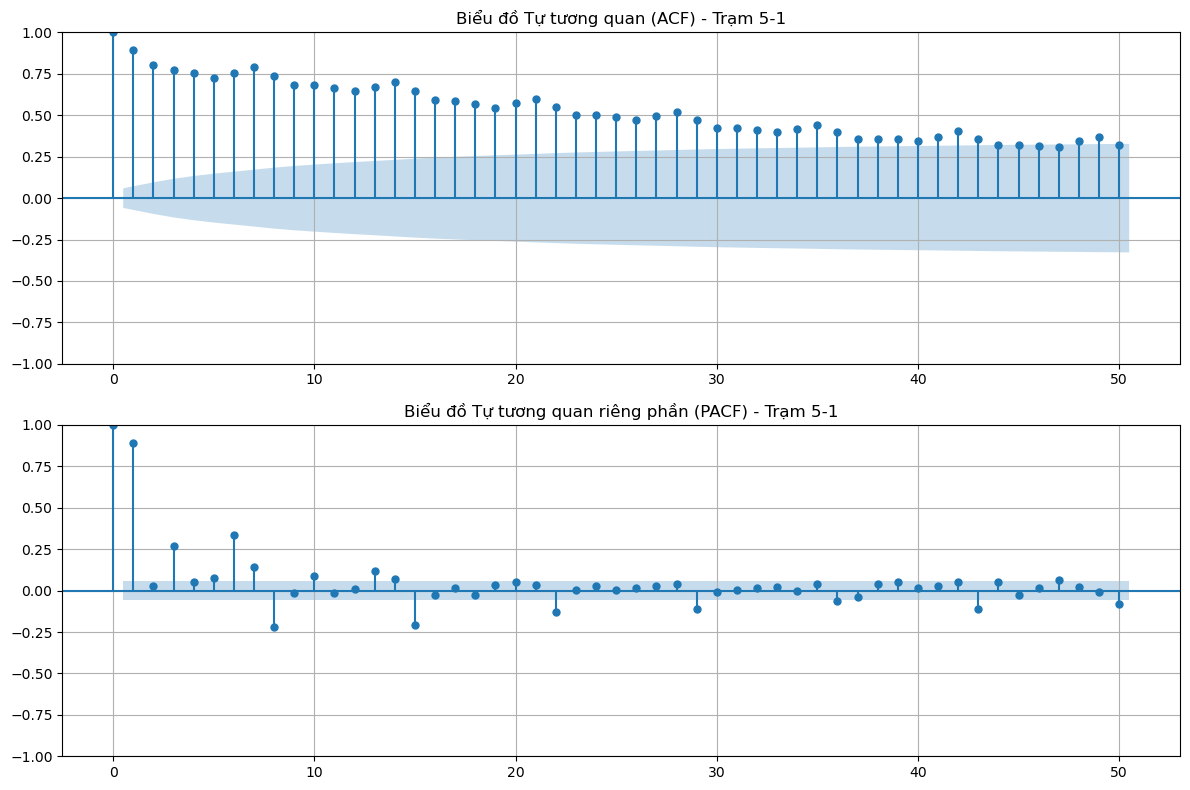

In [22]:

# 1. Đọc và gộp sạch dữ liệu 3 năm cho trạm 5-1

# 2. Thực hiện kiểm định Augmented Dickey-Fuller (ADF)
print("--- KẾT QUẢ KIỂM ĐỊNH ADF ---")
result = adfuller(df_station['5-1'])
print(f"Giá trị thống kê ADF (ADF Statistic): {result[0]:.4f}")
print(f"Giá trị p-value: {result[1]:.4f}")
print("Các giá trị tới hạn (Critical Values):")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

# 3. Kết luận về tính dừng
if result[1] <= 0.05:
    print("\n Kết luận: p-value <= 0.05. Bác bỏ H0, chuỗi dữ liệu ĐÃ DỪNG.")
else:
    print("\n Kết luận: p-value > 0.05. Chưa thể bác bỏ H0, chuỗi dữ liệu KHÔNG DỪNG.")

# 4. Vẽ đồ thị ACF và PACF để xác định tham số
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Đồ thị ACF
sm.graphics.tsa.plot_acf(df_station['5-1'], lags=50, ax=axes[0])
axes[0].set_title('Biểu đồ Tự tương quan (ACF) - Trạm 5-1')
axes[0].grid(True)

# Đồ thị PACF
sm.graphics.tsa.plot_pacf(df_station['5-1'], lags=50, ax=axes[1], method='ywm')
axes[1].set_title('Biểu đồ Tự tương quan riêng phần (PACF) - Trạm 5-1')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('acf_pacf_station_5_1.png')
plt.show()

Mô hình SARIMA đầy đủ có dạng cấu hình tổng quát là:


$$\text{SARIMA}(p, d, q) \times (P, D, Q)_s$$

**Trong đó:**

* **Phần phi mùa vụ (Non-seasonal):** $p$ (Bậc tự hồi quy AR), $d$ (Bậc sai phân tổng thể - ở Bước 2 ta xác định $d=0$), $q$ (Bậc trung bình trượt MA).
* **Phần mùa vụ (Seasonal):** $P$ (Bậc tự hồi quy mùa vụ), $D$ (Bậc sai phân mùa vụ - ở đây $D=0$ do dữ liệu gốc đã dừng), $Q$ (Bậc trung bình trượt mùa vụ).
* **$s = 7$:** Độ dài chu kỳ mùa vụ tính theo ngày (Tuần tuần hoàn 7 ngày).

#### Tiêu chí đánh giá toán học: AIC (Akaike Information Criterion)

Để biết cấu hình nào (ví dụ giữa $\text{SARIMA}(1,0,1)\times(1,0,0)_7$ và $\text{SARIMA}(2,0,2)\times(1,0,1)_7$) là tối ưu nhất, thuật toán sẽ dựa trên chỉ số **AIC** được tính bằng công thức:

$$\text{AIC} = 2k - 2\ln(\hat{L})$$

**Ý nghĩa các thành phần:**

* $k$: Số lượng tham số mà mô hình phải ước lượng (Càng nhiều tham số, mô hình càng cồng kềnh và dễ bị quá khớp - Overfitting).
* $\hat{L}$: Giá trị cực đại của hàm hợp lý (Maximum Likelihood) của mô hình (Đo lường mức độ khớp/giải thích dữ liệu của mô hình).

**Quy tắc chọn tham số:** Mục tiêu của thuật toán Quét lưới (Grid Search) là tìm ra tổ hợp tham số sao cho **chỉ số AIC đạt giá trị NHỎ NHẤT**. Công thức AIC đóng vai trò như một cán cân: Nó vừa phạt mô hình nếu cố tình thêm quá nhiều tham số phụ ($2k$), vừa thưởng nếu mô hình khớp tốt với dữ liệu ($-2\ln(\hat{L})$). Cấu hình đạt AIC thấp nhất chính là điểm cân bằng hoàn hảo.



In [23]:
import pandas as pd
import numpy as np
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Đọc và gộp sạch dữ liệu 3 năm cho trạm 5-1
files = ["extracted-sheets/2021-Daily Traffic Summary.csv", "extracted-sheets/2022-Daily Traffic Summary.csv", "extracted-sheets/2023-Daily Traffic Summary.csv"]
dfs = []

for f in files:
    df = pd.read_csv(f)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date'])
    df['5-1'] = pd.to_numeric(df['5-1'], errors='coerce')
    dfs.append(df[['Date', '5-1']])

df_all = pd.concat(dfs, ignore_index=True).sort_values(by='Date').reset_index(drop=True)
df_all['5-1'] = df_all['5-1'].interpolate(method='linear')
df_all.set_index('Date', inplace=True)

# Đảm bảo tần suất dữ liệu là Daily ('D') liên tục không đứt đoạn
df_daily = df_all.resample('D').mean().interpolate(method='linear')

# 2. Định nghĩa không gian tìm kiếm tham số (Grid Search)
p = [1, 2]
q = [1, 2]
P = [0, 1]
Q = [0, 1]

# Tạo danh sách các tổ hợp phi mùa vụ (d=0) và mùa vụ (D=0, s=7)
pdq = list(itertools.product(p, [0], q))
seasonal_pdq = [(x[0], 0, x[1], 7) for x in list(itertools.product(P, Q))]

best_aic = float("inf")
best_order = None
best_seasonal = None
best_model_results = None

print("--- BẮT ĐẦU QUÉT TÌM BỘ THAM SỐ TỐI ƯU ---")
for order in pdq:
    for seasonal_order in seasonal_pdq:
        try:
            # Khởi tạo mô hình SARIMAX với từng tổ hợp tham số
            model = SARIMAX(df_daily['5-1'],
                            order=order,
                            seasonal_order=seasonal_order,
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            results = model.fit(disp=False)
            
            # Cập nhật nếu tìm thấy AIC nhỏ hơn
            if results.aic < best_aic:
                best_aic = results.aic
                best_order = order
                best_seasonal = seasonal_order
                best_model_results = results
        except:
            continue

# 3. In kết quả tối ưu nhất
print("\n--- KẾT QUẢ TỐI ƯU NHẤT THU ĐƯỢC ---")
print(f"Cấu hình tốt nhất: SARIMA{best_order} x {best_seasonal}")
print(f"Chỉ số AIC nhỏ nhất: {best_aic:.4f}")
print("\nBảng tóm tắt thông số chi tiết của mô hình chiến thắng:")
print(best_model_results.summary())

--- BẮT ĐẦU QUÉT TÌM BỘ THAM SỐ TỐI ƯU ---

--- KẾT QUẢ TỐI ƯU NHẤT THU ĐƯỢC ---
Cấu hình tốt nhất: SARIMA(2, 0, 2) x (1, 0, 1, 7)
Chỉ số AIC nhỏ nhất: 13400.3073

Bảng tóm tắt thông số chi tiết của mô hình chiến thắng:
                                      SARIMAX Results                                      
Dep. Variable:                                 5-1   No. Observations:                 1096
Model:             SARIMAX(2, 0, 2)x(1, 0, [1], 7)   Log Likelihood               -6693.154
Date:                             Mon, 25 May 2026   AIC                          13400.307
Time:                                     15:48:06   BIC                          13435.239
Sample:                                 01-01-2021   HQIC                         13413.531
                                      - 01-01-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z 

Forecast evaluation metrics:
  metric        value
     MAE   130.750267
     MSE 22676.253609
    RMSE   150.586366
 MAPE(%)    42.449925
sMAPE(%)    59.299178


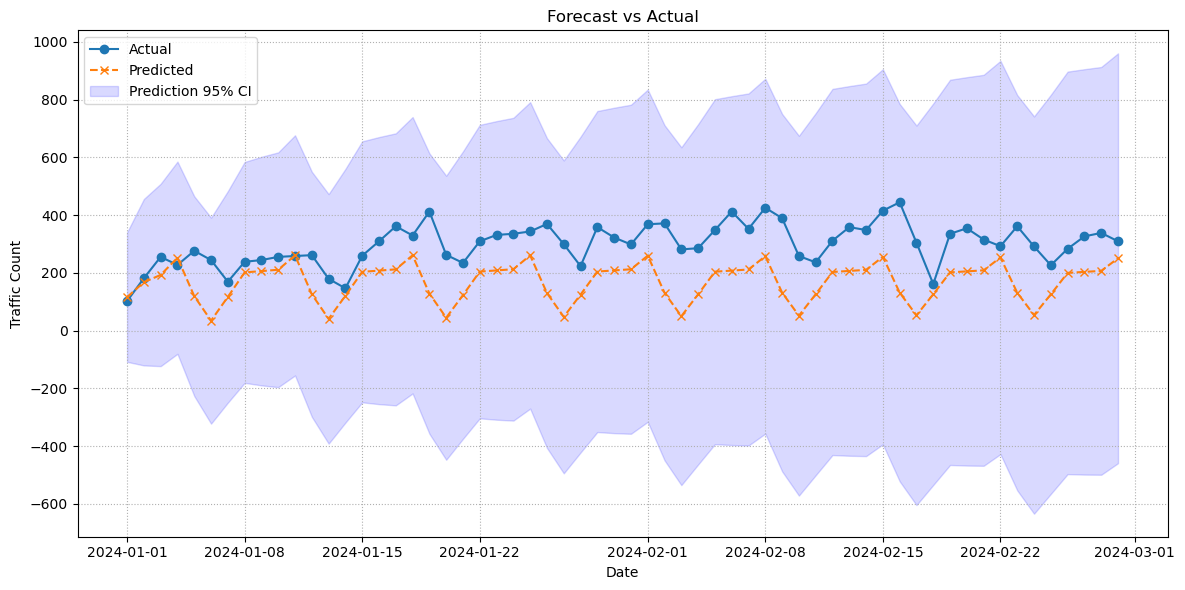

In [28]:
# Cell: Forecast evaluation — compute metrics, plot, and save results
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load the actual 2024 test data
if 'df_2024_test' in globals():
    df_2024_test_use = df_2024_test.copy()
else:
    df_2024 = pd.read_csv('extracted-sheets/2024-Daily Traffic Summary.csv')
    df_2024['Date'] = pd.to_datetime(df_2024['Date'], errors='coerce', format='mixed')
    df_2024 = df_2024.dropna(subset=['Date']).copy()
    df_2024['5-1'] = pd.to_numeric(df_2024['5-1'], errors='coerce')
    df_2024_test_use = df_2024[df_2024['5-1'].notnull()].sort_values(by='Date').reset_index(drop=True)

if df_2024_test_use.empty:
    raise RuntimeError('Không có dữ liệu thực tế 2024 để đánh giá.')

# Determine forecasted series
predicted = None
forecast_res = None

if 'predicted_values' in globals():
    predicted = np.asarray(predicted_values)
elif 'predictions_rolling' in globals():
    predicted = np.asarray(predictions_rolling)
elif 'best_model_results' in globals():
    n_steps = len(df_2024_test_use)
    forecast_res = best_model_results.get_forecast(steps=n_steps)
    predicted = np.asarray(forecast_res.predicted_mean)
else:
    raise RuntimeError('Không có biến dự báo hoặc mô hình SARIMA trong kernel. Vui lòng chạy ô huấn luyện mô hình trước.')

# Align actual and predicted lengths
n = min(len(df_2024_test_use), len(predicted))
if n == 0:
    raise RuntimeError('Không có dữ liệu dự báo hoặc dữ liệu thực tế để đánh giá.')

df_2024_test_use = df_2024_test_use.iloc[:n]
predicted = predicted[:n]
dates = pd.to_datetime(df_2024_test_use['Date'])
actual = np.asarray(df_2024_test_use['5-1'].values)

# Compute metrics
mae = mean_absolute_error(actual, predicted)
mse = mean_squared_error(actual, predicted)
rmse = np.sqrt(mse)
with np.errstate(divide='ignore', invalid='ignore'):
    mape = np.mean(np.abs((actual - predicted) / np.where(actual == 0, np.nan, actual))) * 100
    mape = np.nan if np.isnan(mape) else mape
smape = 100 * np.mean(2 * np.abs(predicted - actual) / (np.abs(actual) + np.abs(predicted) + 1e-9))

metrics = pd.DataFrame({
    'metric': ['MAE', 'MSE', 'RMSE', 'MAPE(%)', 'sMAPE(%)'],
    'value': [mae, mse, rmse, mape, smape]
})
metrics.to_csv('forecast_evaluation_metrics.csv', index=False)

# Prepare prediction interval if available
lower_ci = None
upper_ci = None
if forecast_res is not None:
    try:
        sf = forecast_res.summary_frame()
        if 'mean_ci_lower' in sf.columns and 'mean_ci_upper' in sf.columns:
            lower_ci = sf['mean_ci_lower'].values[:n]
            upper_ci = sf['mean_ci_upper'].values[:n]
    except Exception:
        lower_ci = None
        upper_ci = None

results_df = pd.DataFrame({
    'Date': dates.dt.strftime('%Y-%m-%d'),
    'actual': actual,
    'predicted': predicted
})
if lower_ci is not None and upper_ci is not None:
    results_df['lower_ci'] = lower_ci
    results_df['upper_ci'] = upper_ci
results_df.to_csv('forecast_evaluation.csv', index=False)

print('Forecast evaluation metrics:')
print(metrics.to_string(index=False))

plt.figure(figsize=(12, 6))
plt.plot(dates, actual, label='Actual', marker='o')
plt.plot(dates, predicted, label='Predicted', marker='x', linestyle='--')
if lower_ci is not None and upper_ci is not None:
    plt.fill_between(dates, lower_ci, upper_ci, color='blue', alpha=0.15, label='Prediction 95% CI')
plt.title('Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Traffic Count')
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()
